creating a movie predicition system which helps people in suggesting a movie based on their recent watchlist or wishlist and liked movies


**file requirements.txt**

pandas

matplotlib

scikit-learn

scipy

seaborn

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch
df1=pd.read_csv('movies.csv')

In [ ]:
df.head()

,movie_id,title,genre,release_year
0,1,Rest.,Horror,1986
1,2,Sport admit.,Sci-Fi,1987
2,3,Term reality.,Horror,1981
3,4,Government your only.,Thriller,2020
4,5,Her pretty north.,Mystery,1983


In [ ]:
df2=pd.read_csv('ratings.csv')

merging two csv files so that we can get gener,rating


In [ ]:
merged_df = pd.merge(df1, df2, on='movie_id', how='inner')

verifying whether the two rows are merged or not


In [ ]:
print("Shape of df1:", df1.shape)
print("Shape of df2:", df2.shape)
print("Shape of merged_df:", merged_df.shape)
print("\nFirst few rows:")
print(merged_df.head())

Shape of df1: (100, 4)
Shape of df2: (500, 3)
Shape of merged_df: (500, 6)

First few rows:
   movie_id         title   genre  release_year  user_id  rating
0         1         Rest.  Horror          1986       33       5
1         1         Rest.  Horror          1986        4       3
2         1         Rest.  Horror          1986       20       1
3         1         Rest.  Horror          1986       48       2
4         2  Sport admit.  Sci-Fi          1987       24       5


removing duplicate values after merging the files


In [ ]:
print("Duplicates in df1:", df1['movie_id'].duplicated().sum())
print("Duplicates in df2:", df2['movie_id'].duplicated().sum())

Duplicates in df1: 0
Duplicates in df2: 401


checking whether there are any blanks or gaps in columns

In [ ]:
print(df1.isnull().sum())

movie_id        0
title           0
genre           0
release_year    0
dtype: int64


In [ ]:
print(df2.isnull().sum())

user_id     0
movie_id    0
rating      0
dtype: int64


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
movie_stats = df2.groupby('movie_id').agg(
    avg_rating=('rating', 'mean'),
    popularity=('rating', 'count')
).reset_index()
combined_df = pd.merge(df1, movie_stats, on='movie_id', how='inner')
genre_dummies = combined_df['genre'].str.get_dummies()
features = pd.concat([combined_df[['avg_rating', 'popularity']], genre_dummies], axis=1)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)
print("Feature matrix ready! Shape:", scaled_features.shape)

Feature matrix ready! Shape: (99, 11)


In [ ]:
from sklearn.cluster import KMeans

# We'll start with 5 clusters as an estimate
k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
combined_df['kmeans_cluster'] = kmeans.fit_predict(scaled_features)

print("K-Means clustering finished!")

K-Means clustering finished!


In [ ]:
# Run Hierarchical Clustering
hierarchical = AgglomerativeClustering(n_clusters=k, linkage='ward')
combined_df['hier_cluster'] = hierarchical.fit_predict(scaled_features)

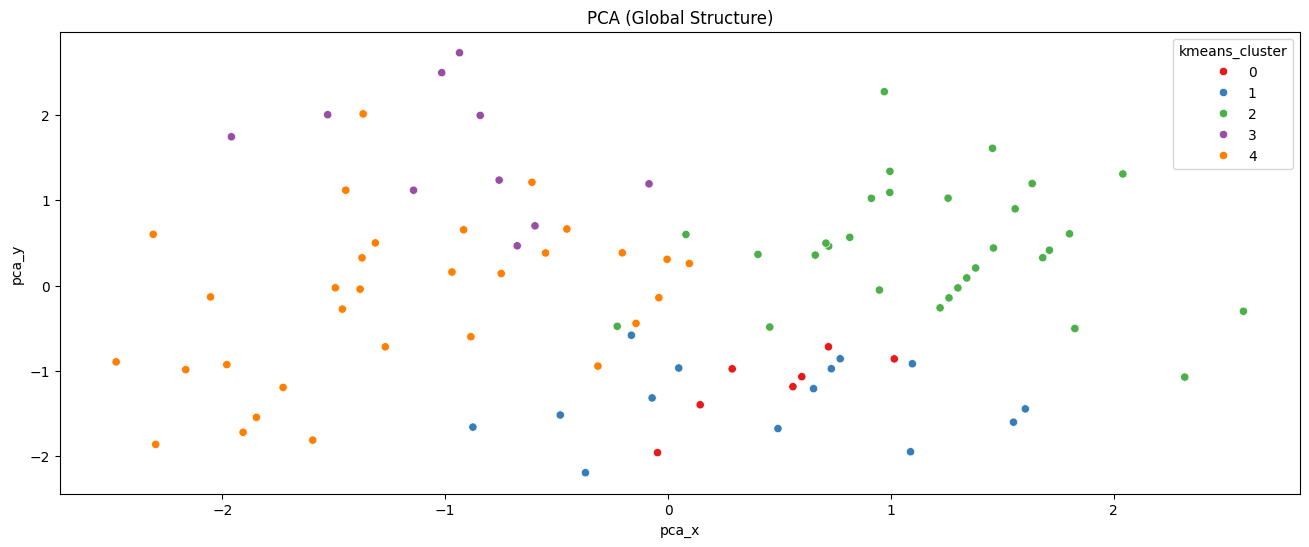

In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import seaborn as sns

# PCA Reduction
pca = PCA(n_components=2)
pca_res = pca.fit_transform(scaled_features)
combined_df['pca_x'], combined_df['pca_y'] = pca_res[:, 0], pca_res[:, 1]
fig, (ax1) = plt.subplots(figsize=(16, 6))


sns.scatterplot(x='pca_x', y='pca_y', hue='kmeans_cluster', data=combined_df, ax=ax1, palette='Set1').set_title('PCA (Global Structure)')
plt.show()

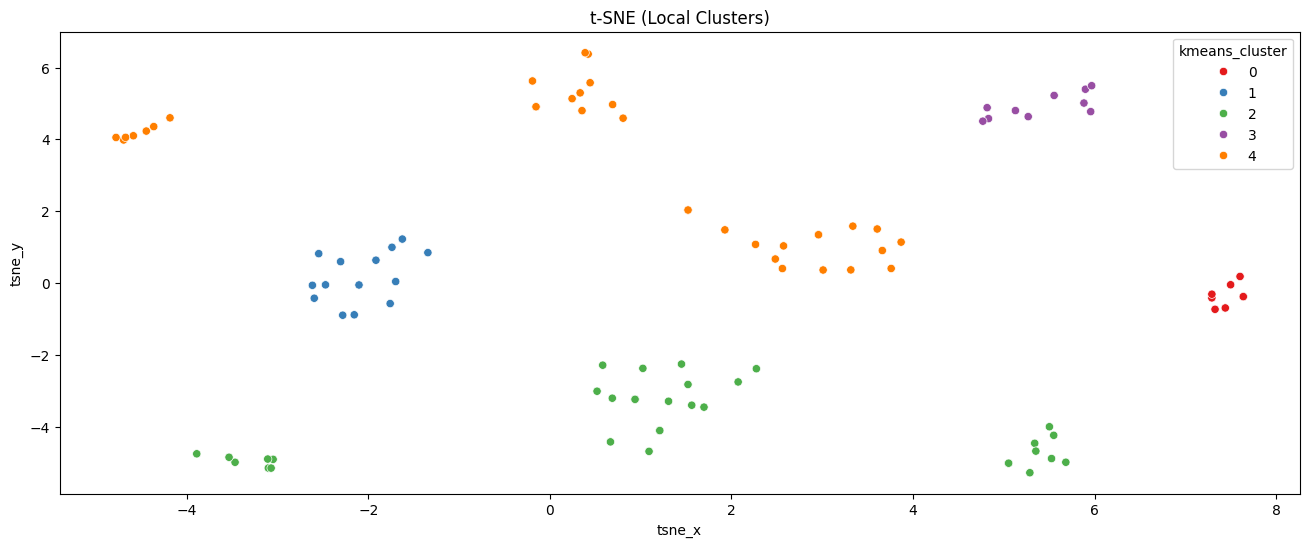

In [ ]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_res = tsne.fit_transform(scaled_features)
combined_df['tsne_x'], combined_df['tsne_y'] = tsne_res[:, 0], tsne_res[:, 1]
fig (ax2) = plt.subplots (figsize=(16, 6))
sns.scatterplot(x='tsne_x', y='tsne_y', hue='kmeans_cluster', data=combined_df, ax=ax2, palette='Set1').set_title('t-SNE (Local Clusters)')
plt.show()